In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/capitoltrades_data.csv', parse_dates=False)

# Basic exploration
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head() 

Dataset shape: (9600, 14)

First few rows:


,politician_name,party,chamber,state,issuer_name,ticker,published_date,traded_date,filed_after_days,owner,transaction_type,size,price,scraped_at
0,Dave McCormick,Republican,Senate,PA,MERCER COUNTY N/A,NaN,04 Mar 2026,9 Feb 2026,22,Self,buy,250K–500K,NaN,2026-03-05 09:34:40
1,Dave McCormick,Republican,Senate,PA,CITY OF PHILADELPHIA PENNSYLVANIA,NaN,04 Mar 2026,18 Feb 2026,13,Spouse,buy,500K–1M,NaN,2026-03-05 09:34:40
2,Dave McCormick,Republican,Senate,PA,DALLAS INDEPENDENT SCHOOL DISTRICT,NaN,04 Mar 2026,18 Feb 2026,13,Spouse,buy,500K–1M,NaN,2026-03-05 09:34:40
3,Dave McCormick,Republican,Senate,PA,GS FINANCE CORP N/A,NaN,04 Mar 2026,17 Feb 2026,14,Spouse,buy,100K–250K,NaN,2026-03-05 09:34:40
4,Dave McCormick,Republican,Senate,PA,GS FINANCE CORP N/A,NaN,04 Mar 2026,17 Feb 2026,14,Spouse,buy,100K–250K,NaN,2026-03-05 09:34:40


In [2]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
df.describe()

Missing values per column:
politician_name        0
party                 28
chamber                0
state                  0
issuer_name            0
ticker              1624
published_date         0
traded_date            0
filed_after_days       0
owner                  0
transaction_type       0
size                   0
price               1921
scraped_at             0
dtype: int64

Data types:
politician_name     object
party               object
chamber             object
state               object
issuer_name         object
ticker              object
published_date      object
traded_date         object
filed_after_days     int64
owner               object
transaction_type    object
size                object
price               object
scraped_at          object
dtype: object

Basic statistics:


,filed_after_days
count,9600.000000
mean,62.762604
std,111.944568
min,0.000000
25%,21.000000
50%,28.000000
75%,40.000000
max,917.000000


In [3]:
# Check unique values
print(f"Number of unique senators: {df['politician_name'].nunique()}")
print(f"Number of unique tickers: {df['ticker'].nunique()}")
print(f"Transaction types: {df['transaction_type'].unique()}")

# Clean dates before using them for min/max
df['traded_date'] = df['traded_date'].str.replace('Sept', 'Sep', regex=False)
df['traded_date'] = pd.to_datetime(df['traded_date'], errors='coerce')
df = df.dropna(subset=['traded_date'])

print(f"Date range: {df['traded_date'].min()} to {df['traded_date'].max()}")

Number of unique senators: 122
Number of unique tickers: 1189
Transaction types: ['buy' 'sell' 'receive' 'exchange']
Date range: 2023-03-14 00:00:00 to 2026-03-01 00:00:00


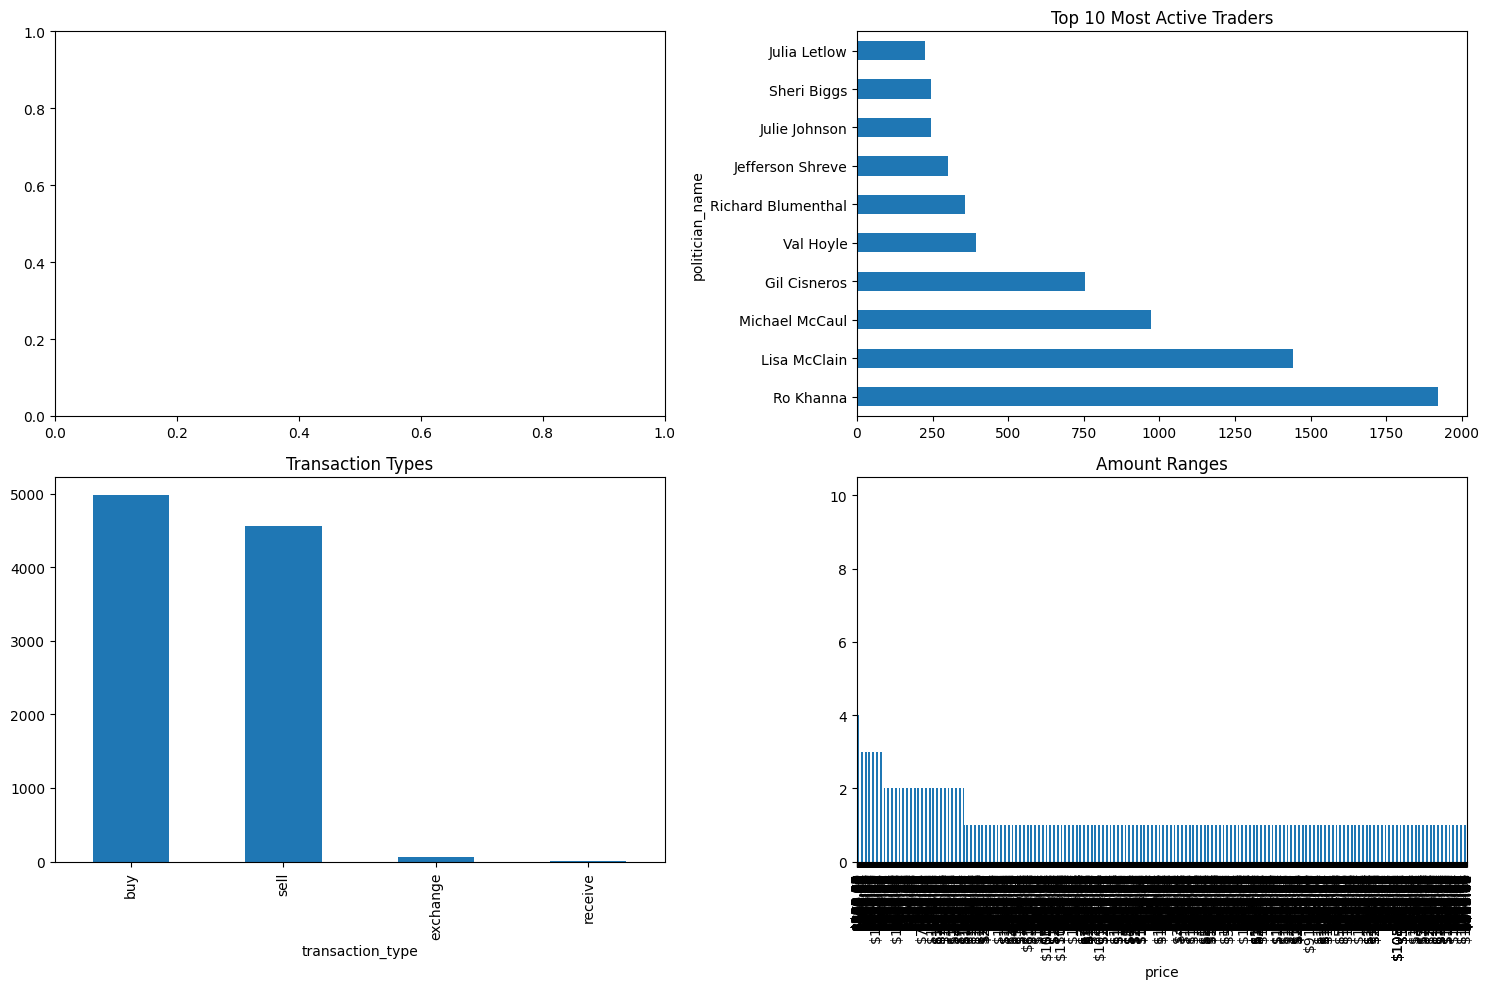

In [7]:
# Quick visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top traders
df['politician_name'].value_counts().head(10).plot(kind='barh', ax=axes[0,1])
axes[0,1].set_title('Top 10 Most Active Traders')

# Transaction types
df['transaction_type'].value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Transaction Types')

# Amount distribution
df['price'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Amount Ranges')

plt.tight_layout()
plt.show()